In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
import cdsapi
import os

print("Все библиотеки загружены!")
print()

# Проверяем данные по населению
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
if os.path.exists(pop_file):
    print("Данные по населению JRC GHSL: найдены!")
else:
    print("Данные по населению: не найдены — нужно скачать заново")

# Проверяем drought данные
drought_file = "C:/Users/Galiya/climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc"
if os.path.exists(drought_file):
    print("Данные по засухе CDD: найдены!")
else:
    print("Данные по засухе: не найдены — нужно скачать заново")
    

Все библиотеки загружены!

Данные по населению JRC GHSL: найдены!
Данные по засухе CDD: найдены!


In [2]:
import cdsapi
c = cdsapi.Client()

# Центральная Азия: Казахстан, Кыргызстан, Таджикистан, Туркменистан, Узбекистан
# Координаты: 35-55°N, 46-87°E
os.makedirs("C:/Users/Galiya/climate_risk_data/central_asia", exist_ok=True)

print("Скачиваем температуру для Центральной Азии...")
c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': [str(y) for y in range(2010, 2024)],
        'month': ['06', '07', '08'],
        'time': '00:00',
        'area': [55, 46, 35, 87],
        'format': 'netcdf'
    },
    'C:/Users/Galiya/climate_risk_data/central_asia/temperature_ca.zip'
)
print("Готово!")

Скачиваем температуру для Центральной Азии...


2026-09-24 11:57:55,335 INFO Request ID is 242527cd-a907-4290-8906-80a3a49f232b
2026-09-24 11:57:55,430 INFO status has been updated to accepted
2026-09-24 11:58:28,164 INFO status has been updated to running
2026-09-24 11:59:11,049 INFO status has been updated to successful


d1c1f615f68fc8458260780be6eb3604.zip:   0%|          | 0.00/4.99M [00:00<?, ?B/s]

Готово!


In [3]:
print("Скачиваем осадки для Центральной Азии...")
c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'total_precipitation',
        'year': [str(y) for y in range(2010, 2024)],
        'month': ['01','02','03','04','05','06',
                  '07','08','09','10','11','12'],
        'time': '00:00',
        'area': [55, 46, 35, 87],
        'format': 'netcdf'
    },
    'C:/Users/Galiya/climate_risk_data/central_asia/precipitation_ca.zip'
)
print("Готово!")

Скачиваем осадки для Центральной Азии...


2026-09-24 12:00:12,777 INFO Request ID is 9accf78a-03ce-438c-b35a-5eea70e4092f
2026-09-24 12:00:14,485 INFO status has been updated to accepted
2026-09-24 12:01:08,282 INFO status has been updated to running
2026-09-24 12:01:33,984 INFO status has been updated to successful


c3bc41b3ad97f35d0efa19c4951ac543.zip:   0%|          | 0.00/36.3M [00:00<?, ?B/s]

Готово!


In [4]:
import zipfile

# Разархивируем температуру
os.makedirs("C:/Users/Galiya/climate_risk_data/central_asia/temp", exist_ok=True)
with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/central_asia/temperature_ca.zip", 'r') as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/central_asia/temp/")

# Разархивируем осадки
os.makedirs("C:/Users/Galiya/climate_risk_data/central_asia/precip", exist_ok=True)
with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/central_asia/precipitation_ca.zip", 'r') as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/central_asia/precip/")

print("Файлы температуры:")
for f in os.listdir("C:/Users/Galiya/climate_risk_data/central_asia/temp/"):
    print(f" — {f}")

print("\nФайлы осадков:")
for f in os.listdir("C:/Users/Galiya/climate_risk_data/central_asia/precip/"):
    print(f" — {f}")

Файлы температуры:
 — data_stream-moda.nc

Файлы осадков:
 — data_stream-moda.nc


In [5]:
import xarray as xr
import numpy as np

# Открываем температуру
temp = xr.open_dataset("C:/Users/Galiya/climate_risk_data/central_asia/temp/data_stream-moda.nc", engine='netcdf4')
t2m = temp['t2m'] - 273.15

# Открываем осадки
precip = xr.open_dataset("C:/Users/Galiya/climate_risk_data/central_asia/precip/data_stream-moda.nc", engine='netcdf4')
tp_annual = precip['tp'] * 1000 * 365

print("Температура:")
print(f"Покрытие: {float(temp.latitude.min()):.1f}-{float(temp.latitude.max()):.1f}N, {float(temp.longitude.min()):.1f}-{float(temp.longitude.max()):.1f}E")
print(f"Мин: {float(t2m.min()):.1f}C, Макс: {float(t2m.max()):.1f}C, Среднее лето: {float(t2m.mean()):.1f}C")
print()
print("Осадки:")
print(f"Мин: {float(tp_annual.min()):.0f}мм, Макс: {float(tp_annual.max()):.0f}мм, Среднее: {float(tp_annual.mean()):.0f}мм")

Температура:
Покрытие: 35.0-55.0N, 46.0-87.0E
Мин: -15.9C, Макс: 37.7C, Среднее лето: 22.4C

Осадки:
Мин: 0мм, Макс: 7752мм, Среднее: 360мм


In [6]:
# Границы стран Центральной Азии [lat_max, lat_min, lon_min, lon_max]
countries_ca = {
    'Kazakhstan':     {'lat': slice(55, 40), 'lon': slice(51, 87)},
    'Kyrgyzstan':     {'lat': slice(43, 39), 'lon': slice(69, 80)},
    'Tajikistan':     {'lat': slice(41, 36), 'lon': slice(67, 75)},
    'Turkmenistan':   {'lat': slice(42, 35), 'lon': slice(52, 63)},
    'Uzbekistan':     {'lat': slice(42, 37), 'lon': slice(56, 73)},
}

print("Летняя температура 2010-2023 (C):")
for country, coords in countries_ca.items():
    subset = t2m.sel(latitude=coords['lat'], longitude=coords['lon']).mean()
    print(f" — {country}: {float(subset):.1f}C")

print()
print("Среднегодовые осадки 2010-2023 (мм/год):")
tp_mean = tp_annual.mean(dim='valid_time')
for country, coords in countries_ca.items():
    subset = tp_mean.sel(latitude=coords['lat'], longitude=coords['lon']).mean()
    print(f" — {country}: {float(subset):.0f}мм")

Летняя температура 2010-2023 (C):
 — Kazakhstan: 22.7C
 — Kyrgyzstan: 15.7C
 — Tajikistan: 14.7C
 — Turkmenistan: 29.2C
 — Uzbekistan: 26.5C

Среднегодовые осадки 2010-2023 (мм/год):
 — Kazakhstan: 351мм
 — Kyrgyzstan: 672мм
 — Tajikistan: 632мм
 — Turkmenistan: 201мм
 — Uzbekistan: 360мм


In [7]:
# Открываем drought данные — глобальные, покрывают Центральную Азию
drought_ds = xr.open_dataset(
    "C:/Users/Galiya/climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc"
)

# Выбираем летний сезон и регион Центральной Азии
drought_ca = drought_ds.CDD.sel(
    time=drought_ds.time.dt.month == 7,
    lat=slice(35, 55),
    lon=slice(46, 87)
).mean(dim='time')

print("Засуха CDD 2041-2070 (дней без осадков летом):")
for country, coords in countries_ca.items():
    subset = drought_ca.sel(
        lat=coords['lat'],
        lon=coords['lon']
    ).mean()
    print(f" — {country}: {float(subset):.1f} дней")

Засуха CDD 2041-2070 (дней без осадков летом):
 — Kazakhstan: nan дней
 — Kyrgyzstan: nan дней
 — Tajikistan: nan дней
 — Turkmenistan: nan дней
 — Uzbekistan: nan дней


In [8]:
# Проверяем координаты drought датасета
print("Drought lat range:", float(drought_ds.lat.min()), "-", float(drought_ds.lat.max()))
print("Drought lon range:", float(drought_ds.lon.min()), "-", float(drought_ds.lon.max()))
print("Первые значения lat:", drought_ds.lat.values[:5])

Drought lat range: -89.75 - 89.75
Drought lon range: -179.75 - 179.75
Первые значения lat: [-89.75 -89.25 -88.75 -88.25 -87.75]


In [9]:
# Проверяем наличие данных для Центральной Азии
drought_ca_check = drought_ds.CDD.sel(
    time=drought_ds.time.dt.month == 7,
    lat=slice(35, 55),
    lon=slice(46, 87)
).mean(dim='time')

print(f"Размер: {drought_ca_check.shape}")
print(f"Среднее: {float(drought_ca_check.mean()):.1f}")
print(f"Мин: {float(drought_ca_check.min()):.1f}")
print(f"Макс: {float(drought_ca_check.max()):.1f}")

Размер: (40, 82)
Среднее: 46.1
Мин: 7.3
Макс: 92.0


In [10]:
# Исправленные границы — lat от меньшего к большему
countries_ca = {
    'Kazakhstan':   {'lat': slice(40, 55), 'lon': slice(51, 87)},
    'Kyrgyzstan':   {'lat': slice(39, 43), 'lon': slice(69, 80)},
    'Tajikistan':   {'lat': slice(36, 41), 'lon': slice(67, 75)},
    'Turkmenistan': {'lat': slice(35, 42), 'lon': slice(52, 63)},
    'Uzbekistan':   {'lat': slice(37, 42), 'lon': slice(56, 73)},
}

print("Засуха CDD 2041-2070 (дней без осадков летом):")
for country, coords in countries_ca.items():
    subset = drought_ca_check.sel(
        lat=coords['lat'],
        lon=coords['lon']
    ).mean()
    print(f" — {country}: {float(subset):.1f} дней")

Засуха CDD 2041-2070 (дней без осадков летом):
 — Kazakhstan: 37.4 дней
 — Kyrgyzstan: 38.8 дней
 — Tajikistan: 63.0 дней
 — Turkmenistan: 82.3 дней
 — Uzbekistan: 78.7 дней


In [11]:
import pandas as pd
import numpy as np

# Данные по населению — World Bank 2020
df = pd.DataFrame({
    'Country': ['Kazakhstan', 'Kyrgyzstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan'],
    'Population_mln': [19.0, 6.6, 9.5, 6.1, 35.3],
    'Density_per_km2': [7, 34, 67, 13, 79],
    'Summer_temp_C': [22.7, 15.7, 14.7, 29.2, 26.5],
    'Precip_mm_year': [351, 672, 632, 201, 360],
    'Drought_CDD_days': [37.4, 38.8, 63.0, 82.3, 78.7],
})

# Нормализация
df['temp_norm'] = (df['Summer_temp_C'] - df['Summer_temp_C'].min()) / (df['Summer_temp_C'].max() - df['Summer_temp_C'].min())
df['precip_norm'] = 1 - ((df['Precip_mm_year'] - df['Precip_mm_year'].min()) / (df['Precip_mm_year'].max() - df['Precip_mm_year'].min()))
df['drought_norm'] = (df['Drought_CDD_days'] - df['Drought_CDD_days'].min()) / (df['Drought_CDD_days'].max() - df['Drought_CDD_days'].min())
df['density_norm'] = (df['Density_per_km2'] - df['Density_per_km2'].min()) / (df['Density_per_km2'].max() - df['Density_per_km2'].min())
df['exposure_score'] = (df['temp_norm'] + df['precip_norm'] + df['drought_norm'] + df['density_norm']) / 4

print("Composite Exposure Score:")
print(df[['Country', 'Summer_temp_C', 'Precip_mm_year', 'Drought_CDD_days', 'Population_mln', 'exposure_score']].to_string(index=False))

Composite Exposure Score:
     Country  Summer_temp_C  Precip_mm_year  Drought_CDD_days  Population_mln  exposure_score
  Kazakhstan           22.7             351              37.4            19.0        0.308313
  Kyrgyzstan           15.7             672              38.8             6.6        0.118786
  Tajikistan           14.7             632              63.0             9.5        0.372104
Turkmenistan           29.2             201              82.3             6.1        0.770833
  Uzbekistan           26.5             360              78.7            35.3        0.849009


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


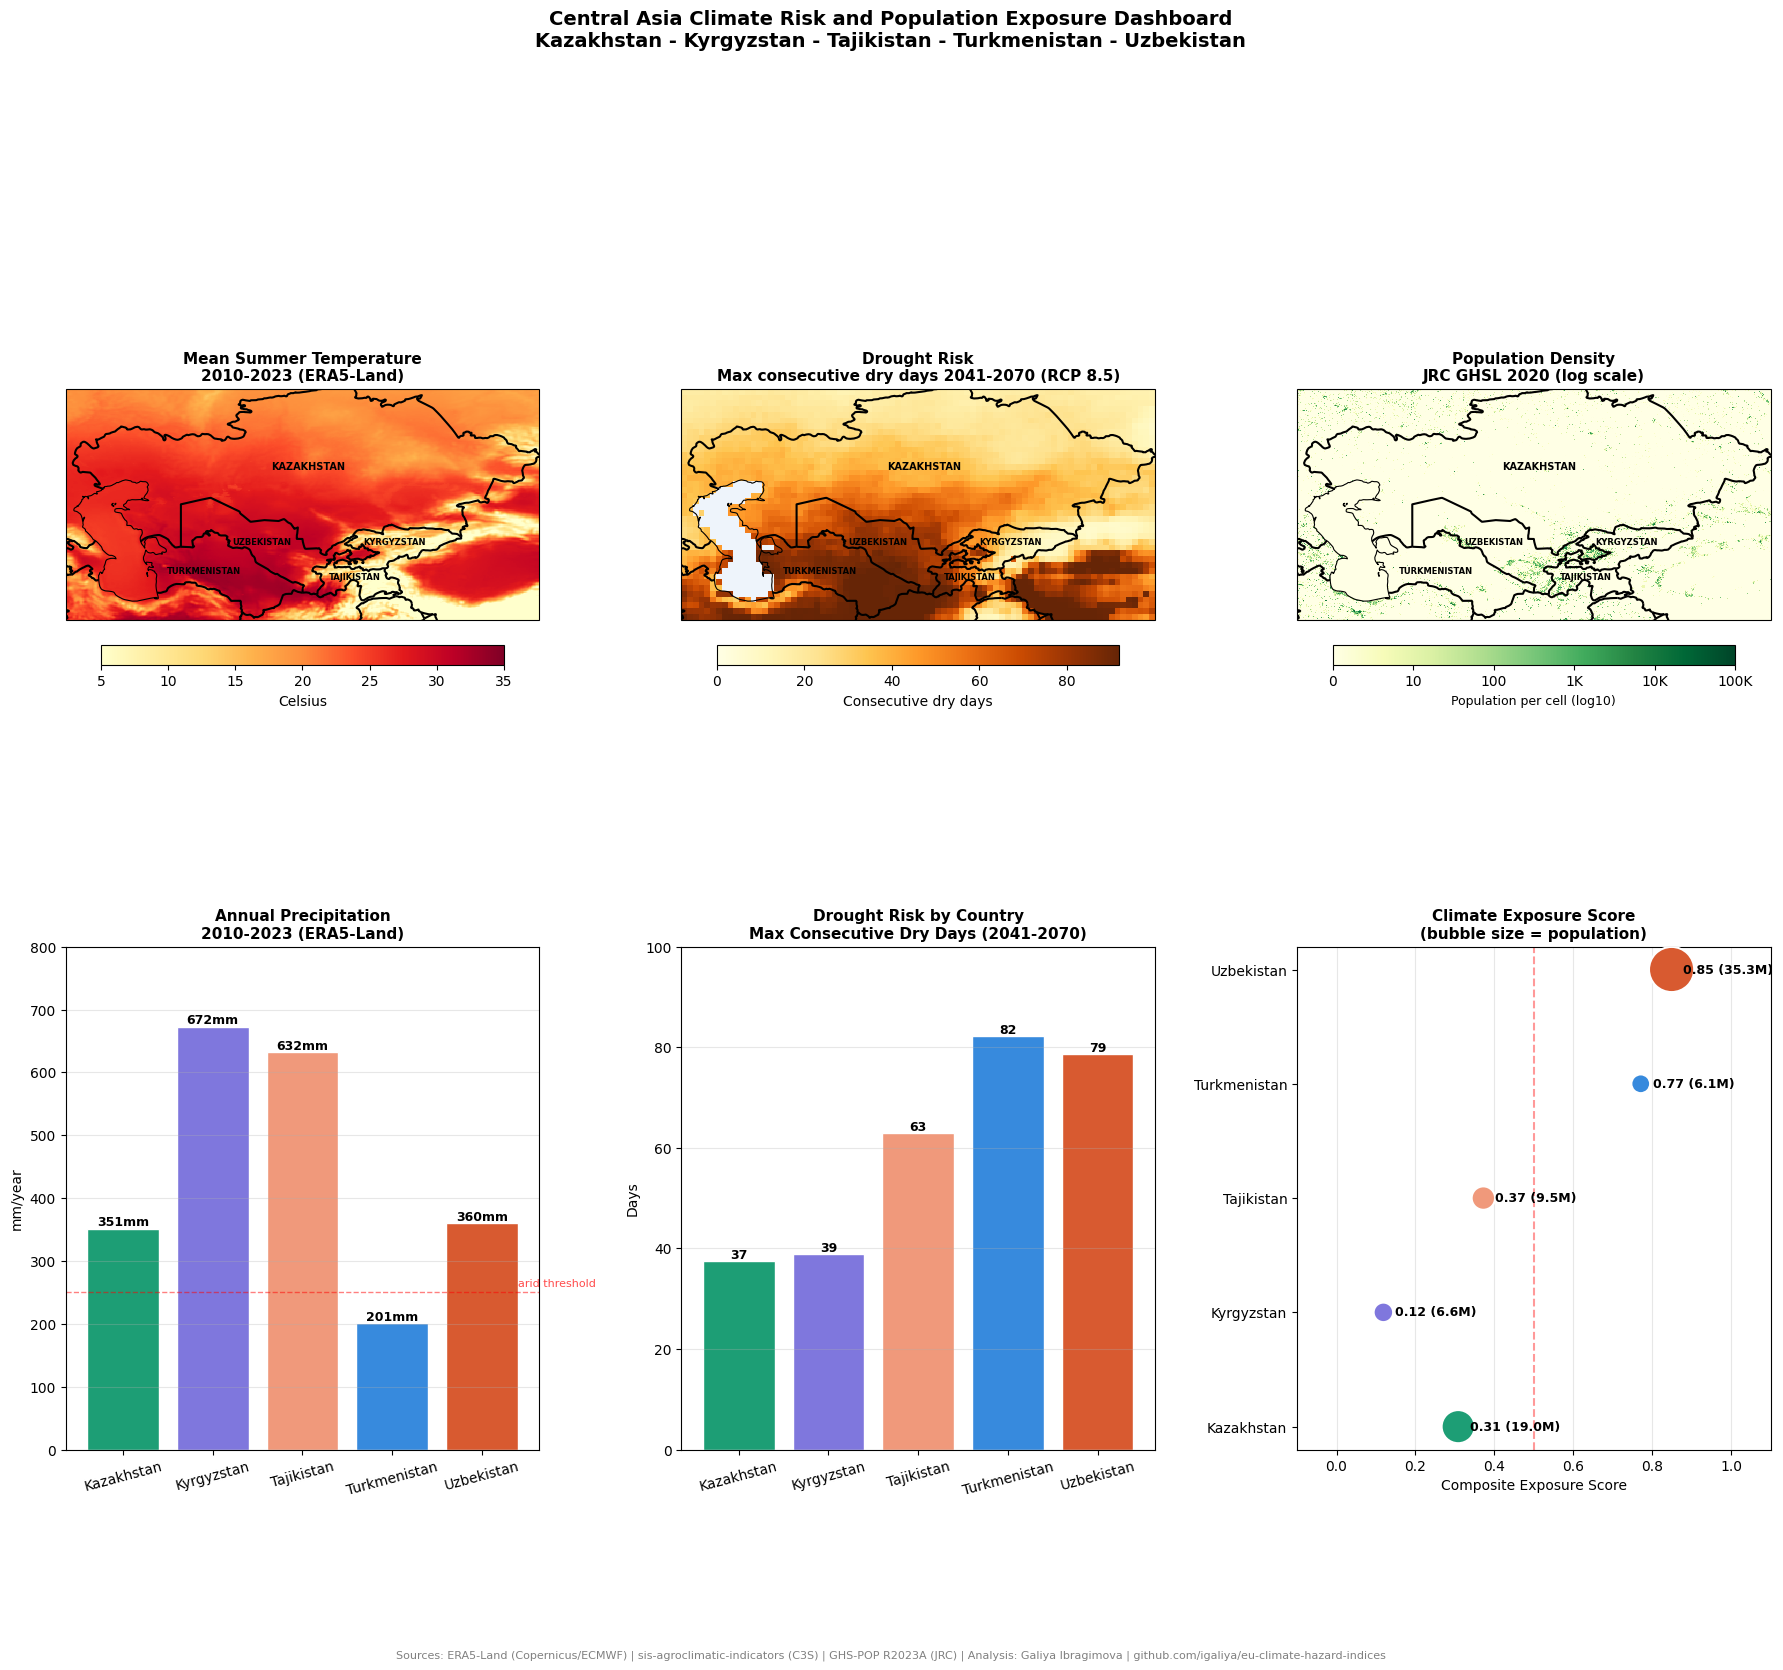

Dashboard saved!


In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [46, 87, 35, 55]
colors = ['#1D9E75', '#7F77DD', '#F0997B', '#378ADD', '#D85A30']
countries_list = df['Country'].tolist()

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(67.0, 48.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_ca_check.lon, drought_ca_check.lat, drought_ca_check, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=92)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(67.0, 48.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(46, 35, 87, 55, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(46, 87, pop_data.shape[1])
lats = np.linspace(55, 35, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(67.0, 48.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
precip_vals = df['Precip_mm_year'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}mm', ha='center', fontsize=9, fontweight='bold')
ax4.set_ylim(0, 800)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=250, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(4.4, 260, 'arid threshold', fontsize=8, color='red', alpha=0.7)
ax4.tick_params(axis='x', rotation=15)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Drought_CDD_days'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim(0, 100)
ax5.grid(axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=15)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Population_mln'].tolist()
ax6.scatter(scores, countries_list, s=[p*30 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.1)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.03, i, f'{score:.2f} ({pop}M)', va='center', fontsize=9, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('Central Asia Climate Risk and Population Exposure Dashboard\nKazakhstan - Kyrgyzstan - Tajikistan - Turkmenistan - Uzbekistan', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.02, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/central_asia_climate_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved!")

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


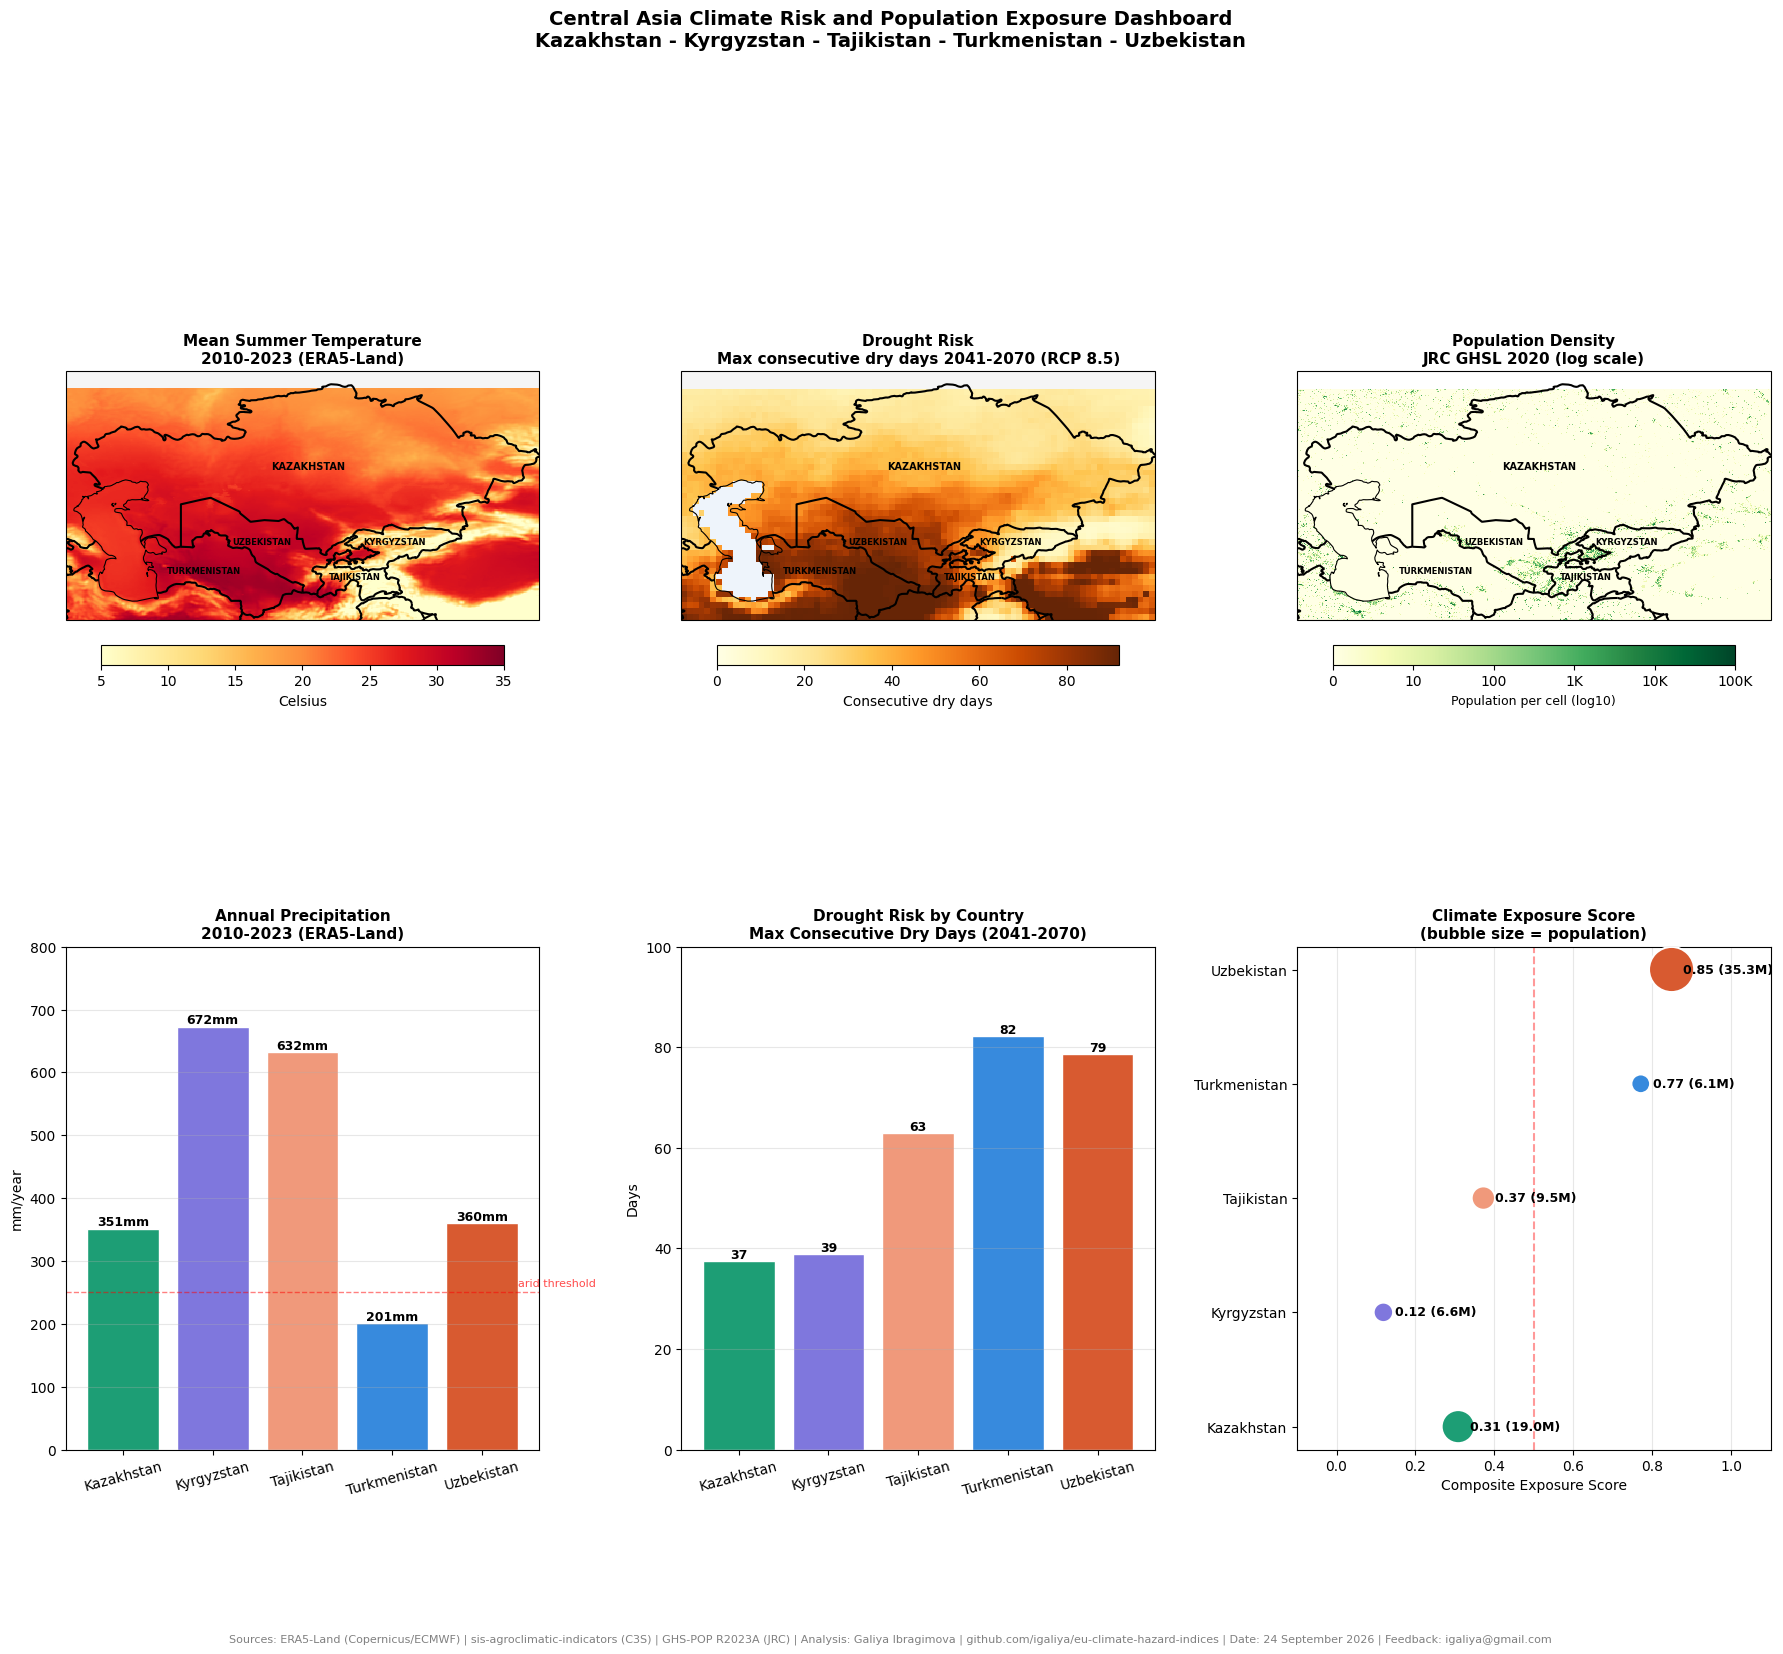

Dashboard saved!


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [46, 87, 35, 56.5]
colors = ['#1D9E75', '#7F77DD', '#F0997B', '#378ADD', '#D85A30']
countries_list = df['Country'].tolist()

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(67.0, 48.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_ca_check.lon, drought_ca_check.lat, drought_ca_check, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=92)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(67.0, 48.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(46, 35, 87, 55, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(46, 87, pop_data.shape[1])
lats = np.linspace(55, 35, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(67.0, 48.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
precip_vals = df['Precip_mm_year'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}mm', ha='center', fontsize=9, fontweight='bold')
ax4.set_ylim(0, 800)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=250, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(4.4, 260, 'arid threshold', fontsize=8, color='red', alpha=0.7)
ax4.tick_params(axis='x', rotation=15)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Drought_CDD_days'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim(0, 100)
ax5.grid(axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=15)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Population_mln'].tolist()
ax6.scatter(scores, countries_list, s=[p*30 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.1)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.03, i, f'{score:.2f} ({pop}M)', va='center', fontsize=9, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('Central Asia Climate Risk and Population Exposure Dashboard\nKazakhstan - Kyrgyzstan - Tajikistan - Turkmenistan - Uzbekistan', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.01, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices | Date: 24 September 2026 | Feedback: igaliya@gmail.com', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/central_asia_climate_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved!")

In [14]:
import cdsapi
c = cdsapi.Client()

print("Скачиваем расширенные данные температуры...")
c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': [str(y) for y in range(2010, 2024)],
        'month': ['06', '07', '08'],
        'time': '00:00',
        'area': [56.5, 46, 35, 87],
        'format': 'netcdf'
    },
    'C:/Users/Galiya/climate_risk_data/central_asia/temperature_ca_v2.zip'
)
print("Готово!")

Скачиваем расширенные данные температуры...


2026-09-24 12:45:15,438 INFO Request ID is 6db7a0ea-1aac-4111-9ece-5e523a2ff824
2026-09-24 12:45:15,754 INFO status has been updated to accepted
2026-09-24 12:45:50,433 INFO status has been updated to successful


f28976058790007fea533fc11cb6fbbb.zip:   0%|          | 0.00/5.33M [00:00<?, ?B/s]

Готово!


In [15]:
print("Скачиваем расширенные данные осадков...")
c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'total_precipitation',
        'year': [str(y) for y in range(2010, 2024)],
        'month': ['01','02','03','04','05','06',
                  '07','08','09','10','11','12'],
        'time': '00:00',
        'area': [56.5, 46, 35, 87],
        'format': 'netcdf'
    },
    'C:/Users/Galiya/climate_risk_data/central_asia/precipitation_ca_v2.zip'
)
print("Готово!")

Скачиваем расширенные данные осадков...


Recovering from HTTP error [502 Bad Gateway], attempt 1 of 500
Retrying in 120 seconds
2026-09-24 12:48:02,223 INFO Request ID is fef137ec-d5a3-4d41-ad4d-7b58f030a92b
2026-09-24 12:48:02,310 INFO status has been updated to accepted
2026-09-24 12:48:36,942 INFO status has been updated to running
2026-09-24 12:49:19,817 INFO status has been updated to successful


8a24e7cc47b39b02983941cf5d7d7338.zip:   0%|          | 0.00/38.7M [00:00<?, ?B/s]

Готово!


In [16]:
import zipfile
import os

# Разархивируем температуру v2
os.makedirs("C:/Users/Galiya/climate_risk_data/central_asia/temp_v2", exist_ok=True)
with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/central_asia/temperature_ca_v2.zip", 'r') as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/central_asia/temp_v2/")

# Разархивируем осадки v2
os.makedirs("C:/Users/Galiya/climate_risk_data/central_asia/precip_v2", exist_ok=True)
with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/central_asia/precipitation_ca_v2.zip", 'r') as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/central_asia/precip_v2/")

# Открываем новые данные
temp2 = xr.open_dataset("C:/Users/Galiya/climate_risk_data/central_asia/temp_v2/data_stream-moda.nc", engine='netcdf4')
t2m2 = temp2['t2m'] - 273.15

precip2 = xr.open_dataset("C:/Users/Galiya/climate_risk_data/central_asia/precip_v2/data_stream-moda.nc", engine='netcdf4')
tp_annual2 = precip2['tp'] * 1000 * 365
tp_mean2 = tp_annual2.mean(dim='valid_time')

print(f"Температура покрытие: {float(temp2.latitude.min()):.1f} — {float(temp2.latitude.max()):.1f}N")
print(f"Осадки покрытие: {float(precip2.latitude.min()):.1f} — {float(precip2.latitude.max()):.1f}N")
print("Готово!")

Температура покрытие: 35.0 — 56.5N
Осадки покрытие: 35.0 — 56.5N
Готово!


In [17]:
print("Летняя температура 2010-2023 (C):")
for country, coords in countries_ca.items():
    subset = t2m2.sel(latitude=coords['lat'], longitude=coords['lon']).mean()
    print(f" — {country}: {float(subset):.1f}C")

print()
print("Среднегодовые осадки 2010-2023 (мм/год):")
for country, coords in countries_ca.items():
    subset = tp_mean2.sel(latitude=coords['lat'], longitude=coords['lon']).mean()
    print(f" — {country}: {float(subset):.0f}мм")

Летняя температура 2010-2023 (C):
 — Kazakhstan: nanC
 — Kyrgyzstan: nanC
 — Tajikistan: nanC
 — Turkmenistan: nanC
 — Uzbekistan: nanC

Среднегодовые осадки 2010-2023 (мм/год):
 — Kazakhstan: nanмм
 — Kyrgyzstan: nanмм
 — Tajikistan: nanмм
 — Turkmenistan: nanмм
 — Uzbekistan: nanмм


In [18]:
print("Первые значения latitude:", temp2.latitude.values[:5])
print("Последние значения latitude:", temp2.latitude.values[-5:])


Первые значения latitude: [56.5 56.4 56.3 56.2 56.1]
Последние значения latitude: [35.4 35.3 35.2 35.1 35. ]


In [19]:
# Исправленные границы — lat от большего к меньшему
countries_ca = {
    'Kazakhstan':   {'lat': slice(55, 40), 'lon': slice(51, 87)},
    'Kyrgyzstan':   {'lat': slice(43, 39), 'lon': slice(69, 80)},
    'Tajikistan':   {'lat': slice(41, 36), 'lon': slice(67, 75)},
    'Turkmenistan': {'lat': slice(42, 35), 'lon': slice(52, 63)},
    'Uzbekistan':   {'lat': slice(42, 37), 'lon': slice(56, 73)},
}

print("Летняя температура 2010-2023 (C):")
for country, coords in countries_ca.items():
    subset = t2m2.sel(latitude=coords['lat'], longitude=coords['lon']).mean()
    print(f" — {country}: {float(subset):.1f}C")

print()
print("Среднегодовые осадки 2010-2023 (мм/год):")
for country, coords in countries_ca.items():
    subset = tp_mean2.sel(latitude=coords['lat'], longitude=coords['lon']).mean()
    print(f" — {country}: {float(subset):.0f}мм")

Летняя температура 2010-2023 (C):
 — Kazakhstan: 22.7C
 — Kyrgyzstan: 15.7C
 — Tajikistan: 14.7C
 — Turkmenistan: 29.2C
 — Uzbekistan: 26.5C

Среднегодовые осадки 2010-2023 (мм/год):
 — Kazakhstan: 351мм
 — Kyrgyzstan: 672мм
 — Tajikistan: 632мм
 — Turkmenistan: 201мм
 — Uzbekistan: 360мм


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


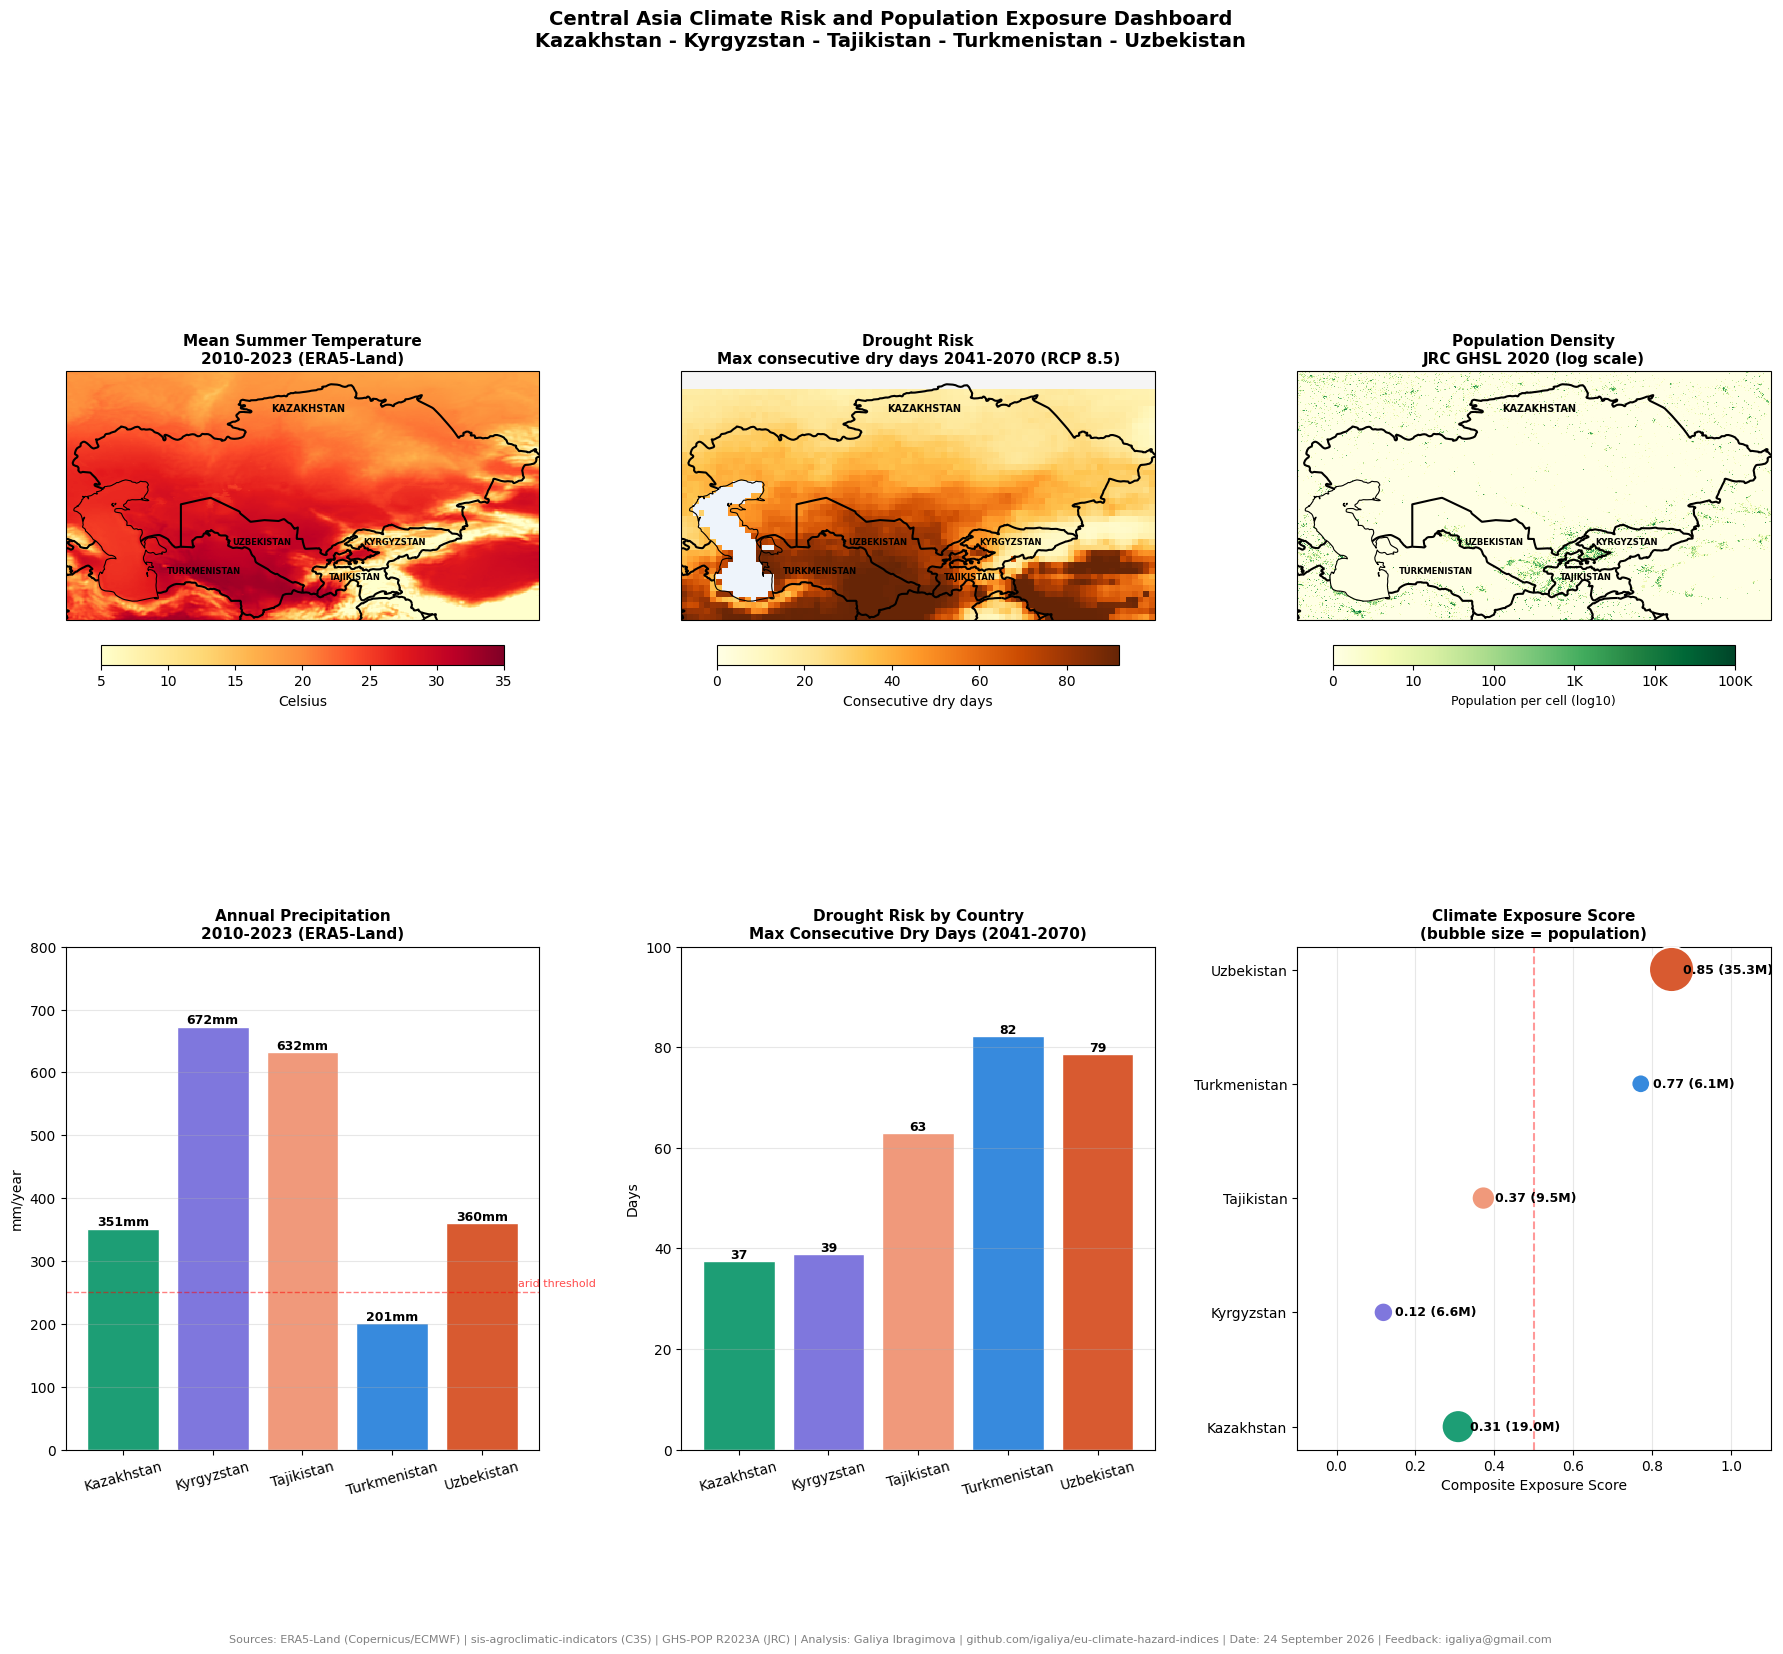

Dashboard saved!


In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [46, 87, 35, 56.5]
colors = ['#1D9E75', '#7F77DD', '#F0997B', '#378ADD', '#D85A30']
countries_list = df['Country'].tolist()

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean2 = t2m2.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp2.longitude, temp2.latitude, t2m_mean2, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(67.0, 53.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_ca_check.lon, drought_ca_check.lat, drought_ca_check, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=92)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(67.0, 53.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(46, 35, 87, 56.5, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(46, 87, pop_data.shape[1])
lats = np.linspace(56.5, 35, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(67.0, 53.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
precip_vals = df['Precip_mm_year'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}mm', ha='center', fontsize=9, fontweight='bold')
ax4.set_ylim(0, 800)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=250, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(4.4, 260, 'arid threshold', fontsize=8, color='red', alpha=0.7)
ax4.tick_params(axis='x', rotation=15)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Drought_CDD_days'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim(0, 100)
ax5.grid(axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=15)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Population_mln'].tolist()
ax6.scatter(scores, countries_list, s=[p*30 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.1)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.03, i, f'{score:.2f} ({pop}M)', va='center', fontsize=9, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('Central Asia Climate Risk and Population Exposure Dashboard\nKazakhstan - Kyrgyzstan - Tajikistan - Turkmenistan - Uzbekistan', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.01, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices | Date: 24 September 2026 | Feedback: igaliya@gmail.com', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/central_asia_climate_dashboard_v2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved!")

In [21]:
print("Drought lat range:", float(drought_ds.lat.min()), "-", float(drought_ds.lat.max()))
print("Drought lon range:", float(drought_ds.lon.min()), "-", float(drought_ds.lon.max()))

Drought lat range: -89.75 - 89.75
Drought lon range: -179.75 - 179.75


In [22]:
# Проверяем drought данные для Центральной Азии с правильными координатами
drought_ca_v2 = drought_ds.CDD.sel(
    time=drought_ds.time.dt.month == 7,
    lat=slice(35, 56.5),
    lon=slice(46, 87)
).mean(dim='time')

print(f"Размер: {drought_ca_v2.shape}")
print(f"Среднее: {float(drought_ca_v2.mean()):.1f}")
print(f"Мин: {float(drought_ca_v2.min()):.1f}")
print(f"Макс: {float(drought_ca_v2.max()):.1f}")
print(f"Lat range: {float(drought_ca_v2.lat.min()):.1f} — {float(drought_ca_v2.lat.max()):.1f}")

Размер: (43, 82)
Среднее: 43.9
Мин: 7.3
Макс: 92.0
Lat range: 35.2 — 56.2


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


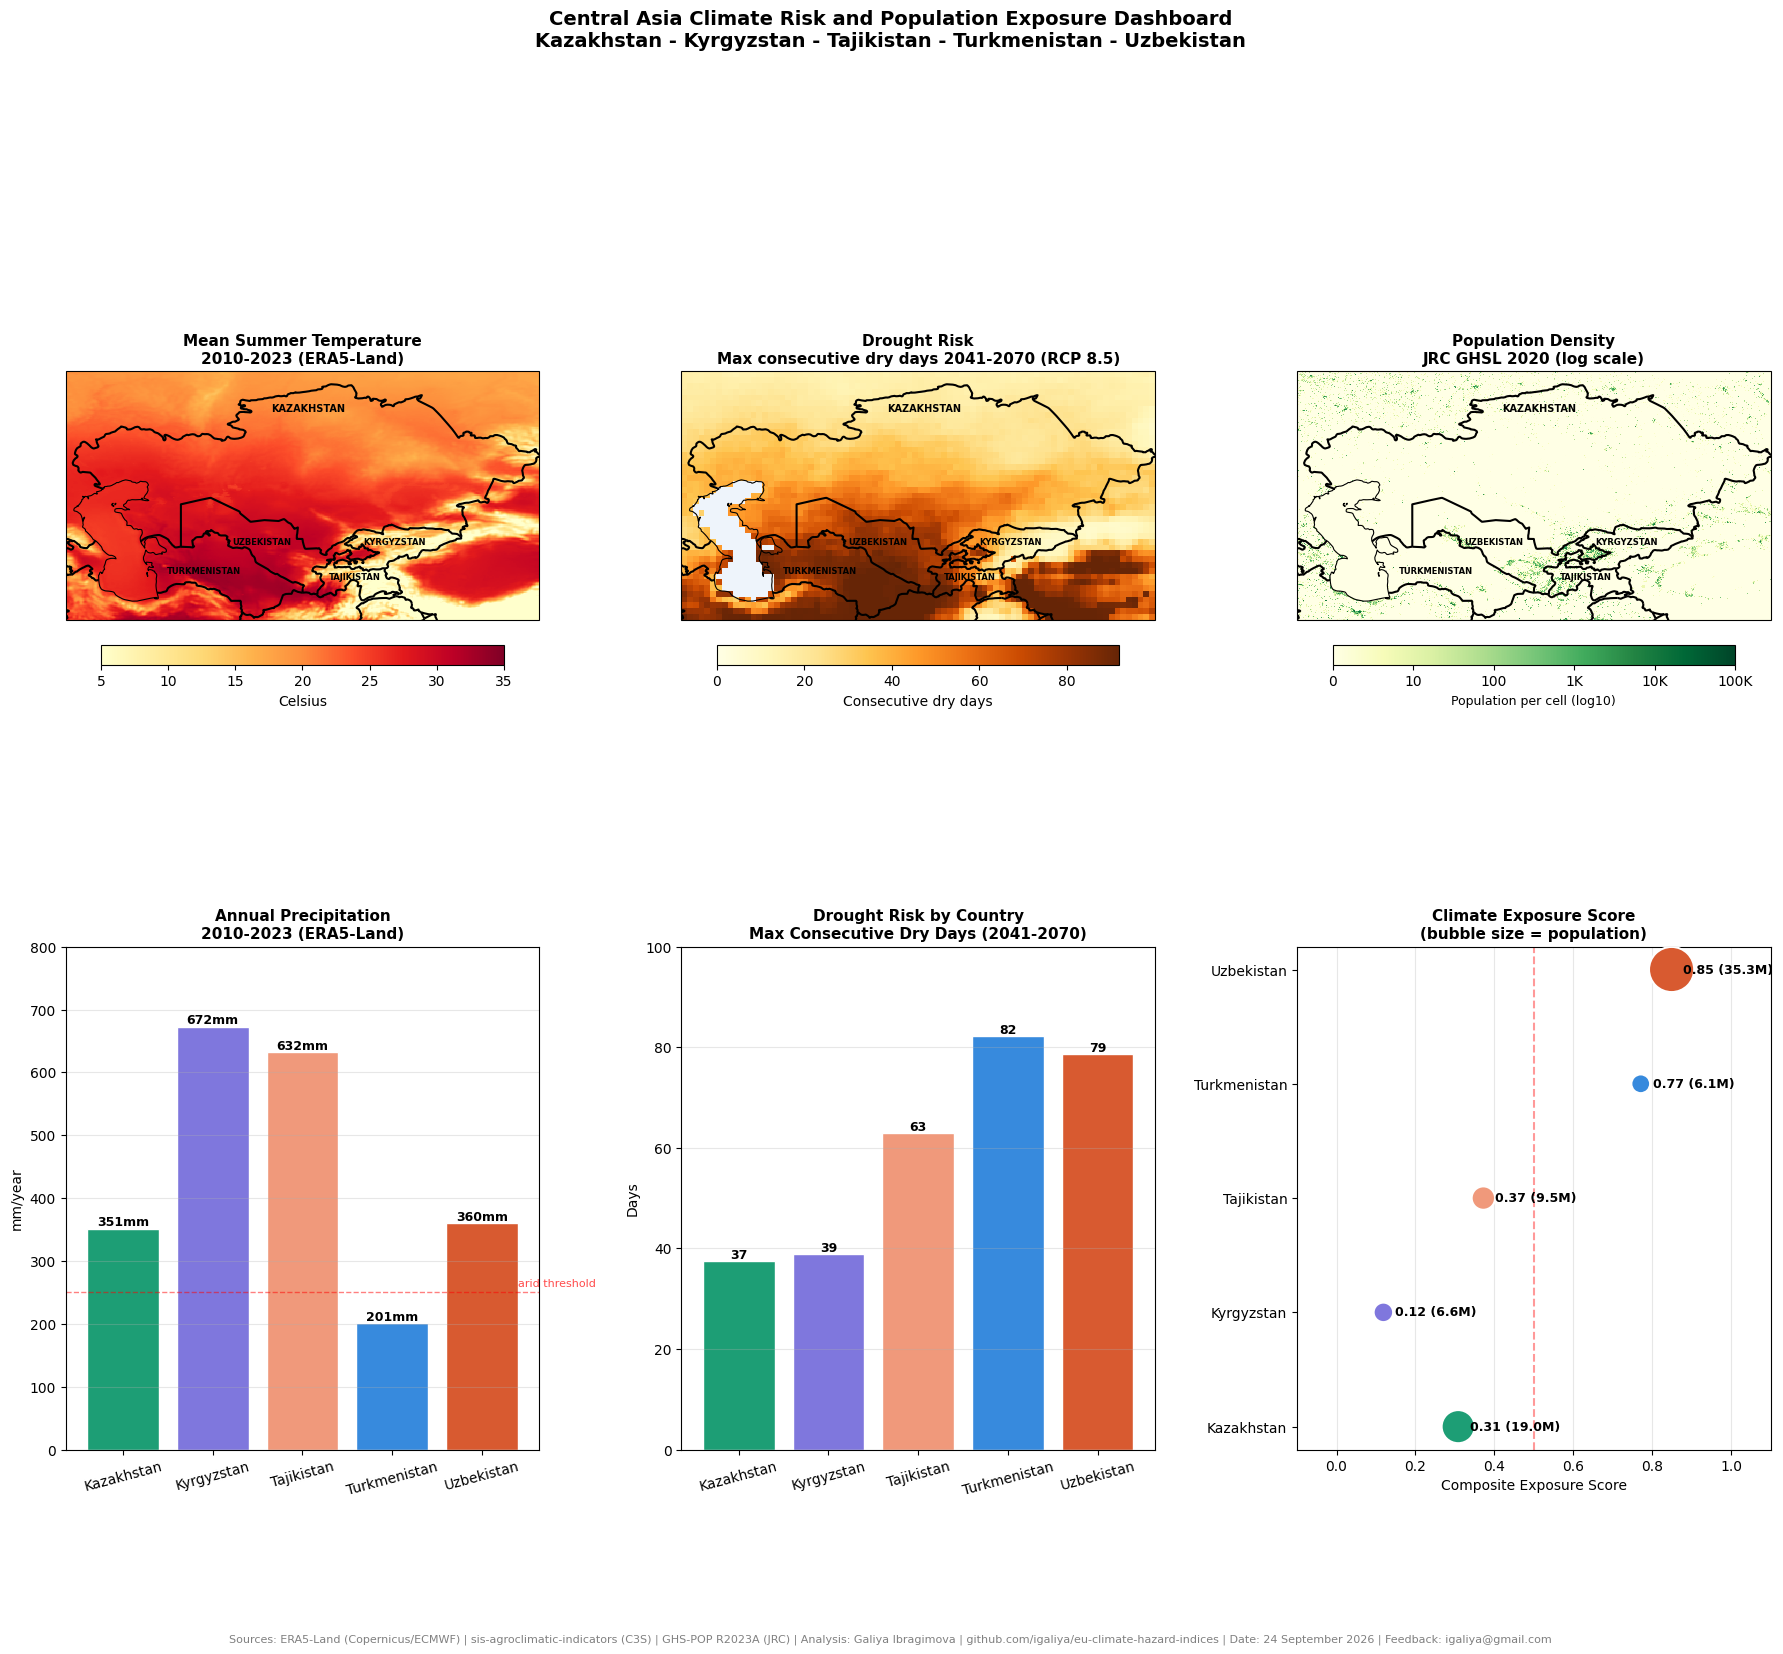

Dashboard saved!


In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [46, 87, 35, 56.5]
colors = ['#1D9E75', '#7F77DD', '#F0997B', '#378ADD', '#D85A30']
countries_list = df['Country'].tolist()

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean2 = t2m2.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp2.longitude, temp2.latitude, t2m_mean2, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(67.0, 53.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА — используем drought_ca_v2
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_ca_v2.lon, drought_ca_v2.lat, drought_ca_v2, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=92)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(67.0, 53.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(46, 35, 87, 56.5, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(46, 87, pop_data.shape[1])
lats = np.linspace(56.5, 35, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(67.0, 53.0, 'KAZAKHSTAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(74.5, 41.5, 'KYRGYZSTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(71.0, 38.5, 'TAJIKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(58.0, 39.0, 'TURKMENISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(63.0, 41.5, 'UZBEKISTAN', transform=ccrs.PlateCarree(), fontsize=6, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
precip_vals = df['Precip_mm_year'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}mm', ha='center', fontsize=9, fontweight='bold')
ax4.set_ylim(0, 800)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=250, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(4.4, 260, 'arid threshold', fontsize=8, color='red', alpha=0.7)
ax4.tick_params(axis='x', rotation=15)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Drought_CDD_days'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_ylim(0, 100)
ax5.grid(axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=15)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Population_mln'].tolist()
ax6.scatter(scores, countries_list, s=[p*30 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.1)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.03, i, f'{score:.2f} ({pop}M)', va='center', fontsize=9, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('Central Asia Climate Risk and Population Exposure Dashboard\nKazakhstan - Kyrgyzstan - Tajikistan - Turkmenistan - Uzbekistan', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.01, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices | Date: 24 September 2026 | Feedback: igaliya@gmail.com', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/central_asia_climate_dashboard_v3.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved!")